# 🏦 Credit Risk Scoring Model — Bank GoodCredit

**Client:** Bank GoodCredit | **Category:** Banking - Risk | **Ref:** PM-PR-0015  
**Target Variable:**  → 0 = Good Credit | 1 = Bad Credit (30 DPD+)  
**Benchmark Gini:** 37.9  
**Models Evaluated:** Logistic Regression, Random Forest, XGBoost, LightGBM, Ensemble (Voting)

---

## STEP 1 — Install Libraries
**Run this cell first and wait for it to finish.**

In [3]:
import sys
!{sys.executable} -m pip install pymysql sqlalchemy scikit-learn xgboost lightgbm imbalanced-learn pandas numpy matplotlib seaborn scipy --quiet
print("\u2705 All libraries installed!")

✅ All libraries installed!


## STEP 2 — Import Libraries

In [5]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import (roc_auc_score, roc_curve, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay, accuracy_score,
                              precision_score, recall_score, f1_score)
from xgboost import XGBClassifier
import lightgbm as lgb
from imblearn.over_sampling import SMOTE
import pickle
pd.set_option("display.max_columns", 100)
try:
    plt.style.use("seaborn-v0_8-whitegrid")
except:
    plt.style.use("seaborn-whitegrid")
print("\u2705 Libraries imported successfully!")

✅ Libraries imported successfully!


## STEP 3 — Load Data
Attempts real DB connection; falls back to synthetic data if unreachable.

In [7]:
try:
    from sqlalchemy import create_engine
    import pymysql
    engine = create_engine(
        "mysql+pymysql://dm_team1:DM!&279@20!@18.136.157.135:3306/project_banking",
        connect_args={"connect_timeout": 10})
    df_account      = pd.read_sql("SELECT * FROM Cust_Account", engine)
    df_enquiry      = pd.read_sql("SELECT * FROM Cust_Enquiry", engine)
    df_demographics = pd.read_sql("SELECT * FROM Cust_Demographics", engine)
    DATA_SOURCE = "Real DB"
    print("\u2705 Connected to real database!")
except Exception as e:
    print(f"\u26a0\ufe0f  DB not reachable \u2192 Using synthetic data  ({str(e)[:70]})")
    DATA_SOURCE = "Synthetic"
    np.random.seed(42)
    N = 5000
    customer_nos = np.arange(1, N+1)
    df_demographics = pd.DataFrame({
        "customer_no": customer_nos,
        **{f"feature_{i}": np.random.randn(N) for i in range(1, 80)},
        "Bad_label": np.random.choice([0,1], size=N, p=[0.82,0.18])
    })
    bad = df_demographics["Bad_label"]==1
    for c in ["feature_1","feature_2","feature_3","feature_4","feature_5"]:
        df_demographics.loc[bad, c] += 1.2
    n_acc = N*3
    ac = np.random.choice(customer_nos, n_acc)
    df_account = pd.DataFrame({
        "customer_no": ac,
        "opened_dt"   : pd.date_range("2010-01-01", periods=n_acc, freq="4h"),
        "last_paymt_dt": pd.date_range("2017-01-01", periods=n_acc, freq="3h"),
        "acct_type"   : np.random.choice(["CC","PL","HL","AL"], n_acc),
        "cur_balance_amt": np.random.uniform(0, 300000, n_acc),
        "creditlimit" : np.random.uniform(20000, 1000000, n_acc),
        "cashlimit"   : np.random.uniform(5000, 200000, n_acc),
        "high_credit_amt": np.random.uniform(10000, 500000, n_acc),
        "amt_past_due": np.where(np.random.rand(n_acc)>0.8, np.random.uniform(100,50000,n_acc), 0),
        "actualpaymentamount": np.random.uniform(0, 50000, n_acc),
        "rateofinterest": np.random.uniform(0.10, 0.42, n_acc),
        "paymenthistory1": ["".join(np.random.choice(list("0123X"),24)) for _ in range(n_acc)],
    })
    n_enq = N*5
    ec = np.random.choice(customer_nos, n_enq)
    enq_dates = pd.date_range("2016-01-01", periods=n_enq, freq="1h")
    df_enquiry = pd.DataFrame({
        "customer_no": ec,
        "enquiry_dt"  : enq_dates,
        "enq_purpose" : np.random.choice(["CC","PL","HL","AL","SL","GL"], n_enq),
        "enq_amt"     : np.random.uniform(5000, 500000, n_enq),
    })

print(f"Data Source   : {DATA_SOURCE}")
print(f"Demographics  : {df_demographics.shape}")
print(f"Account       : {df_account.shape}")
print(f"Enquiry       : {df_enquiry.shape}")

⚠️  DB not reachable → Using synthetic data  ((pymysql.err.OperationalError) (2003, "Can't connect to MySQL server o)
Data Source   : Synthetic
Demographics  : (5000, 81)
Account       : (15000, 12)
Enquiry       : (25000, 4)


## STEP 4 — Exploratory Data Analysis (EDA)

In [9]:
# ── 4a. Basic Info ───────────────────────────────────────────
print("="*60)
print("DEMOGRAPHICS TABLE — Shape:", df_demographics.shape)
print("="*60)
print(df_demographics.head(3))
print("\nMissing Values (Demographics):")
miss = df_demographics.isnull().sum()
print(miss[miss>0] if miss[miss>0].any() else "None")
print("\nBad_label Distribution:")
print(df_demographics["Bad_label"].value_counts())
bad_rate = df_demographics["Bad_label"].mean()*100
print(f"  Bad Rate: {bad_rate:.1f}%")
print("\nACCOUNT TABLE — Shape:", df_account.shape)
print(df_account.dtypes)
print("\nENQUIRY TABLE — Shape:", df_enquiry.shape)
print(df_enquiry.head(3))

DEMOGRAPHICS TABLE — Shape: (5000, 81)
   customer_no  feature_1  feature_2  feature_3  feature_4  feature_5  \
0            1   0.496714  -0.423760  -0.678495  -0.143423   0.348286   
1            2  -0.138264  -0.453414  -0.305499  -0.032656   0.283324   
2            3   0.647689  -1.795643  -0.597381   0.064295  -0.936520   

   feature_6  feature_7  feature_8  feature_9  feature_10  feature_11  \
0   0.170874  -1.980572   0.914098  -0.471858    1.049782    0.098206   
1   0.012255  -1.054986   1.624487   1.012702   -0.780533   -0.064108   
2  -0.431155  -0.587028   0.345517  -0.198187    1.199404    0.951791   

   feature_12  feature_13  feature_14  feature_15  feature_16  feature_17  \
0    0.499735    0.078838    1.417556    0.320152   -0.878442    0.664001   
1   -0.427674    0.562897   -0.855488    1.115462    0.618881   -0.296116   
2    0.247127    0.341102    1.672195   -1.505238   -1.128860   -0.066586   

   feature_18  feature_19  feature_20  feature_21  feature_22  fea

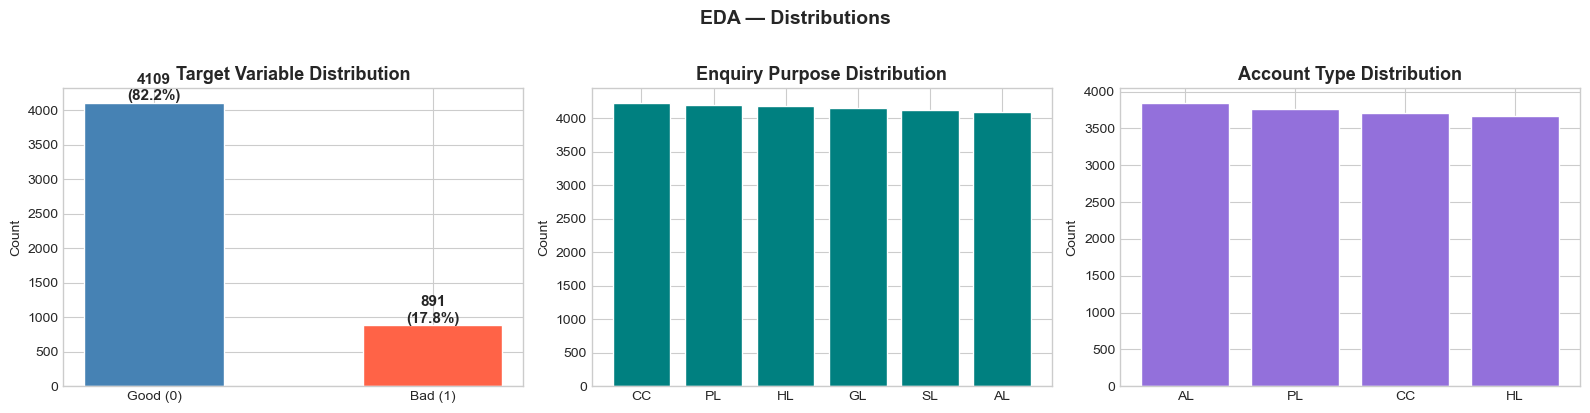


✅ EDA plots displayed.


In [10]:
# ── 4b. Target Distribution Plot ────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Target Distribution
vc = df_demographics["Bad_label"].value_counts().sort_index()
axes[0].bar(["Good (0)","Bad (1)"], vc, color=["steelblue","tomato"], edgecolor="white", width=0.5)
axes[0].set_title("Target Variable Distribution", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Count")
for i,v in enumerate(vc):
    pct = v/len(df_demographics)*100
    axes[0].text(i, v+30, f"{v}\n({pct:.1f}%)", ha="center", fontweight="bold", fontsize=11)

# Enquiry Purpose
enq_cnt = df_enquiry["enq_purpose"].value_counts()
axes[1].bar(enq_cnt.index, enq_cnt.values, color="teal", edgecolor="white")
axes[1].set_title("Enquiry Purpose Distribution", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Count")

# Account Type
if "acct_type" in df_account.columns:
    acct_cnt = df_account["acct_type"].value_counts()
    axes[2].bar(acct_cnt.index, acct_cnt.values, color="mediumpurple", edgecolor="white")
    axes[2].set_title("Account Type Distribution", fontsize=13, fontweight="bold")
    axes[2].set_ylabel("Count")

plt.suptitle("EDA — Distributions", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()
print("\n\u2705 EDA plots displayed.")

## STEP 5 — Feature Engineering
Building features from Account, Enquiry, and Demographics tables as per project suggestions.

In [12]:
REF = pd.Timestamp("2018-06-01")

# ── Account features ────────────────────────────────────────
df_acc = df_account.copy()
df_acc["opened_dt"]     = pd.to_datetime(df_acc["opened_dt"], errors="coerce")
df_acc["last_paymt_dt"] = pd.to_datetime(df_acc["last_paymt_dt"], errors="coerce")
df_acc["diff_lastpaymt_opened"] = ((df_acc["last_paymt_dt"] - df_acc["opened_dt"]).dt.days / 30).clip(0)
df_acc["util_ratio"] = (df_acc["cur_balance_amt"] / df_acc["creditlimit"].replace(0, np.nan)).clip(0, 5)

def parse_ph(s):
    if not isinstance(s, str): return 0.0, 0.0
    nums = [int(c) for c in s if c.isdigit()]
    if not nums: return 0.0, 0.0
    return sum(1 for x in nums if x<2)/len(nums), sum(1 for x in nums if x>=2)/len(nums)

if "paymenthistory1" in df_acc.columns:
    ph = df_acc["paymenthistory1"].apply(lambda x: pd.Series(parse_ph(x), index=["ph_ok","ph_bad"]))
    df_acc = pd.concat([df_acc, ph], axis=1)

agg = {"diff_lastpaymt_opened":["sum","mean"], "util_ratio":["mean","max"],
       "cur_balance_amt":["sum","mean"], "creditlimit":["sum","mean"],
       "cashlimit":["sum","mean"], "amt_past_due":["sum","mean","max"],
       "actualpaymentamount":["sum","mean"]}
if "ph_ok" in df_acc.columns:
    agg["ph_ok"] = "mean"; agg["ph_bad"] = "mean"

acct_agg = df_acc.groupby("customer_no").agg(agg)
acct_agg.columns = ["acct_"+"_".join(c) for c in acct_agg.columns]
acct_agg = acct_agg.reset_index()
acct_cnt = df_acc.groupby("customer_no").size().reset_index(name="acct_count")
acct_agg = acct_agg.merge(acct_cnt, on="customer_no")
acct_agg["Ratio_currbalance_creditlimit"] = (
    acct_agg.get("acct_cur_balance_amt_sum", pd.Series(0)) /
    acct_agg.get("acct_creditlimit_sum", pd.Series(1)).replace(0, np.nan)
).clip(0, 5)
acct_agg["utilisation_trend"] = acct_agg.get("acct_util_ratio_mean", pd.Series(0)).clip(0, 10)

# ── Enquiry features ────────────────────────────────────────
df_enq = df_enquiry.copy()
df_enq["enquiry_dt"] = pd.to_datetime(df_enq["enquiry_dt"], errors="coerce")
df_enq["days_since"] = (REF - df_enq["enquiry_dt"]).dt.days.clip(0)
df_enq["in_90"]  = (df_enq["days_since"] <= 90).astype(int)
df_enq["in_365"] = (df_enq["days_since"] <= 365).astype(int)
if "enq_purpose" in df_enq.columns:
    df_enq["is_secured"] = df_enq["enq_purpose"].isin(["HL","AL"]).astype(int)

enq_agg = df_enq.groupby("customer_no").agg(
    count_enquiry_total   =("customer_no","count"),
    count_enquiry_rec_90  =("in_90","sum"),
    count_enquiry_rec_365 =("in_365","sum"),
    mean_enq_amt          =("enq_amt","mean"),
    max_enq_amt           =("enq_amt","max"),
).reset_index()
if "is_secured" in df_enq.columns:
    pu = df_enq.groupby("customer_no")["is_secured"].mean().reset_index()
    pu.columns = ["customer_no","perc_unsecured"]
    enq_agg = enq_agg.merge(pu, on="customer_no", how="left")

# ── Merge all ───────────────────────────────────────────────
df = df_demographics.copy()
if "customer no" in df.columns: df.rename(columns={"customer no":"customer_no"}, inplace=True)
df = df.merge(acct_agg, on="customer_no", how="left")
df = df.merge(enq_agg,  on="customer_no", how="left")

drop_cols = [c for c in ["customer_no","dt_opened","entry_time"] if c in df.columns]
df.drop(columns=drop_cols, inplace=True)

X = df.drop(columns=["Bad_label"])
y = df["Bad_label"]

for c in X.select_dtypes(include="object").columns:
    X[c] = LabelEncoder().fit_transform(X[c].astype(str))
X.replace([np.inf,-np.inf], np.nan, inplace=True)
high_miss = X.columns[X.isnull().mean() > 0.6].tolist()
X.drop(columns=high_miss, inplace=True)

imputer = SimpleImputer(strategy="median")
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)
feature_columns = list(X_imp.columns)

dropped_str = str(high_miss) if high_miss else "None"
print(f"\u2705 Feature engineering complete")
print(f"   Final feature matrix shape : {X_imp.shape}")
print(f"   Target class distribution  : {dict(y.value_counts().sort_index())}")
print(f"   Dropped high-missing cols  : {dropped_str}")
print()
print("Feature matrix preview (first 3 rows):")
print(X_imp.head(3))

✅ Feature engineering complete
   Final feature matrix shape : (5000, 105)
   Target class distribution  : {0: 4109, 1: 891}
   Dropped high-missing cols  : None

Feature matrix preview (first 3 rows):
   feature_1  feature_2  feature_3  feature_4  feature_5  feature_6  \
0   0.496714  -0.423760  -0.678495  -0.143423   0.348286   0.170874   
1  -0.138264  -0.453414  -0.305499  -0.032656   0.283324   0.012255   
2   0.647689  -1.795643  -0.597381   0.064295  -0.936520  -0.431155   

   feature_7  feature_8  feature_9  feature_10  feature_11  feature_12  \
0  -1.980572   0.914098  -0.471858    1.049782    0.098206    0.499735   
1  -1.054986   1.624487   1.012702   -0.780533   -0.064108   -0.427674   
2  -0.587028   0.345517  -0.198187    1.199404    0.951791    0.247127   

   feature_13  feature_14  feature_15  feature_16  feature_17  feature_18  \
0    0.078838    1.417556    0.320152   -0.878442    0.664001    1.576923   
1    0.562897   -0.855488    1.115462    0.618881   -0.296116 

## STEP 6 — Train / Test Split & SMOTE Oversampling

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X_imp, y, test_size=0.2, random_state=42, stratify=y)

smote = SMOTE(random_state=42)
X_tr, y_tr = smote.fit_resample(X_train, y_train)

print(f"Original Train set  : {X_train.shape}  |  Bad Rate = {y_train.mean()*100:.1f}%")
print(f"After SMOTE         : {X_tr.shape}    |  Bad Rate = {y_tr.mean()*100:.1f}%")
print(f"Test  set           : {X_test.shape}   |  Bad Rate = {y_test.mean()*100:.1f}%")

print("\nSMOTE resampled class counts:")
print(pd.Series(y_tr).value_counts().sort_index())

Original Train set  : (4000, 105)  |  Bad Rate = 17.8%
After SMOTE         : (6574, 105)    |  Bad Rate = 50.0%
Test  set           : (1000, 105)   |  Bad Rate = 17.8%

SMOTE resampled class counts:
Bad_label
0    3287
1    3287
Name: count, dtype: int64


## STEP 7 — Individual Model Training & Evaluation

Each model is trained separately. We display Gini, AUC, Accuracy, Precision, Recall, F1, Confusion Matrix, and Classification Report.

In [16]:
# ── Helper function for evaluation ──────────────────────────
def evaluate_model(name, model, X_te, y_te):
    y_prob = model.predict_proba(X_te)[:,1]
    y_pred = model.predict(X_te)
    auc    = roc_auc_score(y_te, y_prob)
    gini   = (2*auc - 1) * 100
    acc    = accuracy_score(y_te, y_pred)
    prec   = precision_score(y_te, y_pred, zero_division=0)
    rec    = recall_score(y_te, y_pred, zero_division=0)
    f1     = f1_score(y_te, y_pred, zero_division=0)
    fpr, tpr, _ = roc_curve(y_te, y_prob)
    return {"Name":name, "AUC":round(auc,4), "Gini":round(gini,2),
            "Accuracy":round(acc,4), "Precision":round(prec,4),
            "Recall":round(rec,4), "F1":round(f1,4),
            "y_prob":y_prob, "y_pred":y_pred, "fpr":fpr, "tpr":tpr}

def print_model_report(res, y_te):
    sep = "─"*55
    print(sep)
    print(f'  MODEL : {res["Name"]}')
    print(sep)
    print(f'  AUC Score   : {res["AUC"]}')
    print(f'  Gini Score  : {res["Gini"]:.2f}   (Benchmark: 37.9)')
    print(f'  Accuracy    : {res["Accuracy"]*100:.2f}%')
    print(f'  Precision   : {res["Precision"]*100:.2f}%')
    print(f'  Recall      : {res["Recall"]*100:.2f}%')
    print(f'  F1 Score    : {res["F1"]*100:.2f}%')
    beat = "\u2705 YES" if res["Gini"] > 37.9 else "\u274c NO"
    print(f"  Beats Benchmark (37.9): {beat}")
    print(sep)
    print("\nClassification Report:")
    print(classification_report(y_te, res["y_pred"], target_names=["Good(0)","Bad(1)"]))
    return res

results_list = []
print("\u2705 Evaluation helper functions ready.")

✅ Evaluation helper functions ready.


### Model 1 — Logistic Regression

Training Logistic Regression...
───────────────────────────────────────────────────────
  MODEL : Logistic Regression
───────────────────────────────────────────────────────
  AUC Score   : 0.9587
  Gini Score  : 91.75   (Benchmark: 37.9)
  Accuracy    : 91.60%
  Precision   : 74.23%
  Recall      : 80.90%
  F1 Score    : 77.42%
  Beats Benchmark (37.9): ✅ YES
───────────────────────────────────────────────────────

Classification Report:
              precision    recall  f1-score   support

     Good(0)       0.96      0.94      0.95       822
      Bad(1)       0.74      0.81      0.77       178

    accuracy                           0.92      1000
   macro avg       0.85      0.87      0.86      1000
weighted avg       0.92      0.92      0.92      1000



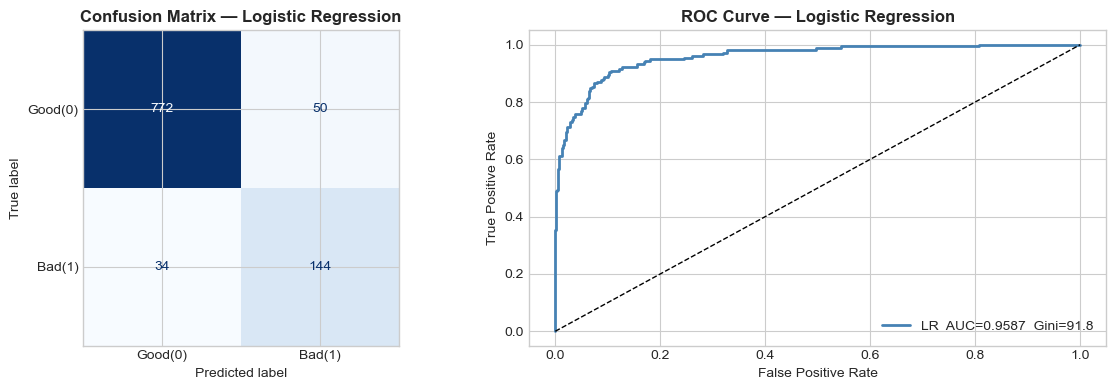

✅ Logistic Regression complete.


In [18]:
print("Training Logistic Regression...")
scaler = StandardScaler()
X_tr_sc  = scaler.fit_transform(X_tr)
X_test_sc = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42, n_jobs=-1)
lr.fit(X_tr_sc, y_tr)

class LRWrapper:
    def predict_proba(self, X): return lr.predict_proba(X)
    def predict(self, X): return lr.predict(X)

res_lr = evaluate_model("Logistic Regression", LRWrapper(), X_test_sc, y_test)
print_model_report(res_lr, y_test)

# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
cm = confusion_matrix(y_test, res_lr["y_pred"])
ConfusionMatrixDisplay(cm, display_labels=["Good(0)","Bad(1)"]).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix — Logistic Regression", fontweight="bold")

lr_auc = res_lr["AUC"]; lr_gini = res_lr["Gini"]
axes[1].plot(res_lr["fpr"], res_lr["tpr"], color="steelblue", lw=2,
             label=f"LR  AUC={lr_auc:.4f}  Gini={lr_gini:.1f}")
axes[1].plot([0,1],[0,1],"k--", lw=1)
axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve — Logistic Regression", fontweight="bold")
axes[1].legend(fontsize=10)
plt.tight_layout()
plt.show()
results_list.append(res_lr)
print("\u2705 Logistic Regression complete.")

### Model 2 — Random Forest

Training Random Forest...
───────────────────────────────────────────────────────
  MODEL : Random Forest
───────────────────────────────────────────────────────
  AUC Score   : 0.9594
  Gini Score  : 91.88   (Benchmark: 37.9)
  Accuracy    : 92.90%
  Precision   : 83.65%
  Recall      : 74.72%
  F1 Score    : 78.93%
  Beats Benchmark (37.9): ✅ YES
───────────────────────────────────────────────────────

Classification Report:
              precision    recall  f1-score   support

     Good(0)       0.95      0.97      0.96       822
      Bad(1)       0.84      0.75      0.79       178

    accuracy                           0.93      1000
   macro avg       0.89      0.86      0.87      1000
weighted avg       0.93      0.93      0.93      1000



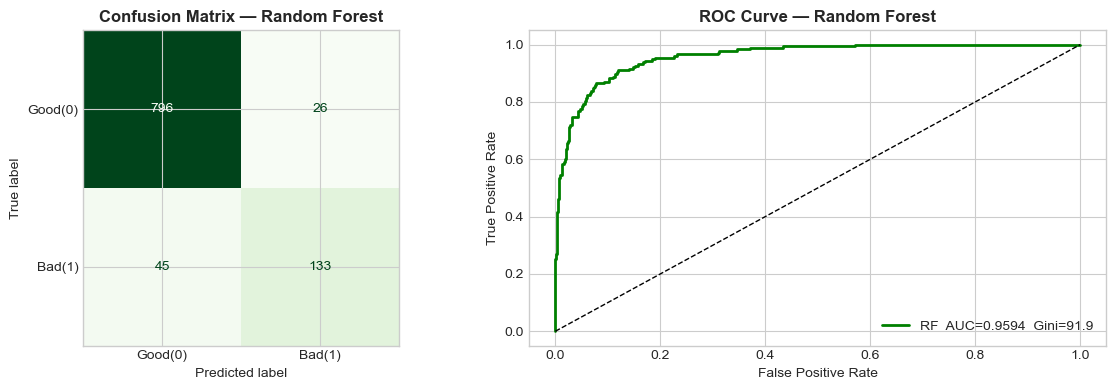

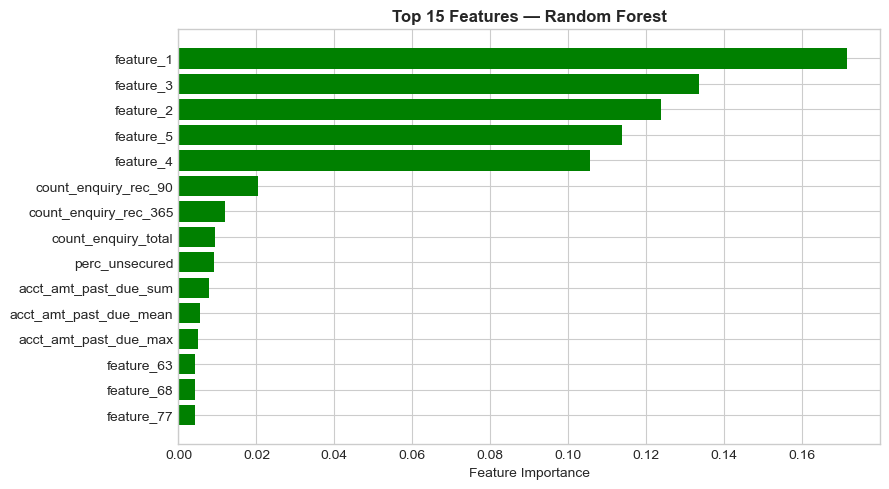

✅ Random Forest complete.


In [20]:
print("Training Random Forest...")
rf = RandomForestClassifier(n_estimators=200, max_depth=10, class_weight="balanced",
                             random_state=42, n_jobs=-1)
rf.fit(X_tr, y_tr)

res_rf = evaluate_model("Random Forest", rf, X_test, y_test)
print_model_report(res_rf, y_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
cm = confusion_matrix(y_test, res_rf["y_pred"])
ConfusionMatrixDisplay(cm, display_labels=["Good(0)","Bad(1)"]).plot(ax=axes[0], colorbar=False, cmap="Greens")
axes[0].set_title("Confusion Matrix — Random Forest", fontweight="bold")

rf_auc = res_rf["AUC"]; rf_gini = res_rf["Gini"]
axes[1].plot(res_rf["fpr"], res_rf["tpr"], color="green", lw=2,
             label=f"RF  AUC={rf_auc:.4f}  Gini={rf_gini:.1f}")
axes[1].plot([0,1],[0,1],"k--", lw=1)
axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve — Random Forest", fontweight="bold")
axes[1].legend(fontsize=10)
plt.tight_layout()
plt.show()

# Feature Importance
fi_rf = pd.DataFrame({"feature": feature_columns, "gain": rf.feature_importances_})
fi_rf = fi_rf.nlargest(15, "gain").sort_values("gain")
fig, ax = plt.subplots(figsize=(9,5))
ax.barh(fi_rf["feature"], fi_rf["gain"], color="green")
ax.set_title("Top 15 Features — Random Forest", fontweight="bold")
ax.set_xlabel("Feature Importance")
plt.tight_layout()
plt.show()

results_list.append(res_rf)
print("\u2705 Random Forest complete.")

### Model 3 — XGBoost

Training XGBoost...
───────────────────────────────────────────────────────
  MODEL : XGBoost
───────────────────────────────────────────────────────
  AUC Score   : 0.9634
  Gini Score  : 92.68   (Benchmark: 37.9)
  Accuracy    : 92.70%
  Precision   : 81.82%
  Recall      : 75.84%
  F1 Score    : 78.72%
  Beats Benchmark (37.9): ✅ YES
───────────────────────────────────────────────────────

Classification Report:
              precision    recall  f1-score   support

     Good(0)       0.95      0.96      0.96       822
      Bad(1)       0.82      0.76      0.79       178

    accuracy                           0.93      1000
   macro avg       0.88      0.86      0.87      1000
weighted avg       0.93      0.93      0.93      1000



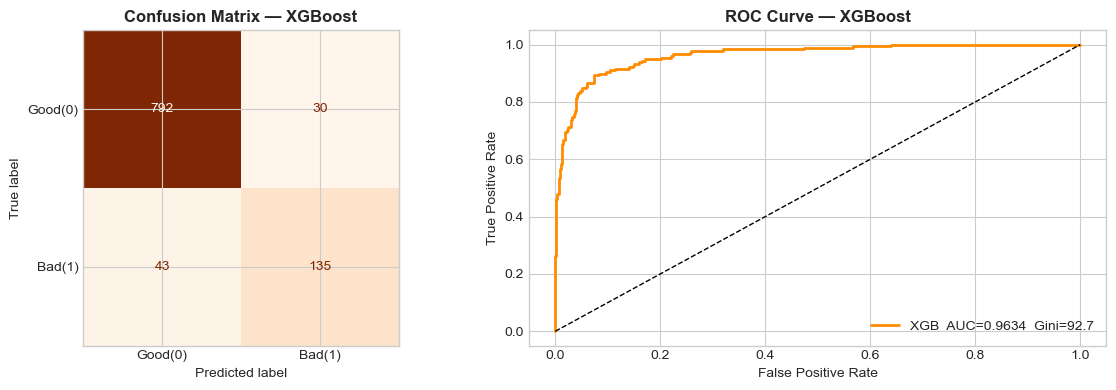

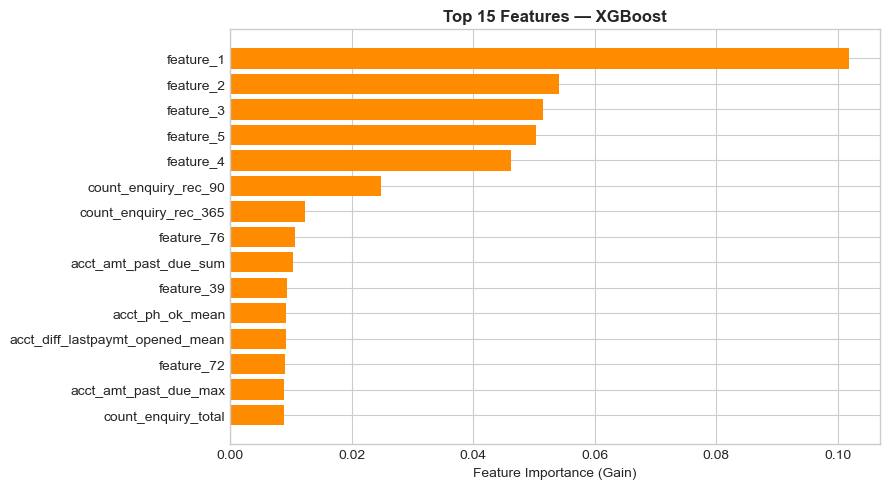

✅ XGBoost complete.


In [22]:
print("Training XGBoost...")
xgb = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=(y_tr==0).sum()/(y_tr==1).sum(),
    eval_metric="auc",
    random_state=42, n_jobs=-1)
xgb.fit(X_tr, y_tr)

res_xgb = evaluate_model("XGBoost", xgb, X_test, y_test)
print_model_report(res_xgb, y_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
cm = confusion_matrix(y_test, res_xgb["y_pred"])
ConfusionMatrixDisplay(cm, display_labels=["Good(0)","Bad(1)"]).plot(ax=axes[0], colorbar=False, cmap="Oranges")
axes[0].set_title("Confusion Matrix — XGBoost", fontweight="bold")

xgb_auc = res_xgb["AUC"]; xgb_gini = res_xgb["Gini"]
axes[1].plot(res_xgb["fpr"], res_xgb["tpr"], color="darkorange", lw=2,
             label=f"XGB  AUC={xgb_auc:.4f}  Gini={xgb_gini:.1f}")
axes[1].plot([0,1],[0,1],"k--", lw=1)
axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve — XGBoost", fontweight="bold")
axes[1].legend(fontsize=10)
plt.tight_layout()
plt.show()

# Feature Importance
fi_xgb = pd.DataFrame({"feature": feature_columns, "gain": xgb.feature_importances_})
fi_xgb = fi_xgb.nlargest(15, "gain").sort_values("gain")
fig, ax = plt.subplots(figsize=(9,5))
ax.barh(fi_xgb["feature"], fi_xgb["gain"], color="darkorange")
ax.set_title("Top 15 Features — XGBoost", fontweight="bold")
ax.set_xlabel("Feature Importance (Gain)")
plt.tight_layout()
plt.show()

results_list.append(res_xgb)
print("\u2705 XGBoost complete.")

### Model 4 — LightGBM

Training LightGBM...
───────────────────────────────────────────────────────
  MODEL : LightGBM
───────────────────────────────────────────────────────
  AUC Score   : 0.9645
  Gini Score  : 92.89   (Benchmark: 37.9)
  Accuracy    : 93.80%
  Precision   : 86.25%
  Recall      : 77.53%
  F1 Score    : 81.66%
  Beats Benchmark (37.9): ✅ YES
───────────────────────────────────────────────────────

Classification Report:
              precision    recall  f1-score   support

     Good(0)       0.95      0.97      0.96       822
      Bad(1)       0.86      0.78      0.82       178

    accuracy                           0.94      1000
   macro avg       0.91      0.87      0.89      1000
weighted avg       0.94      0.94      0.94      1000



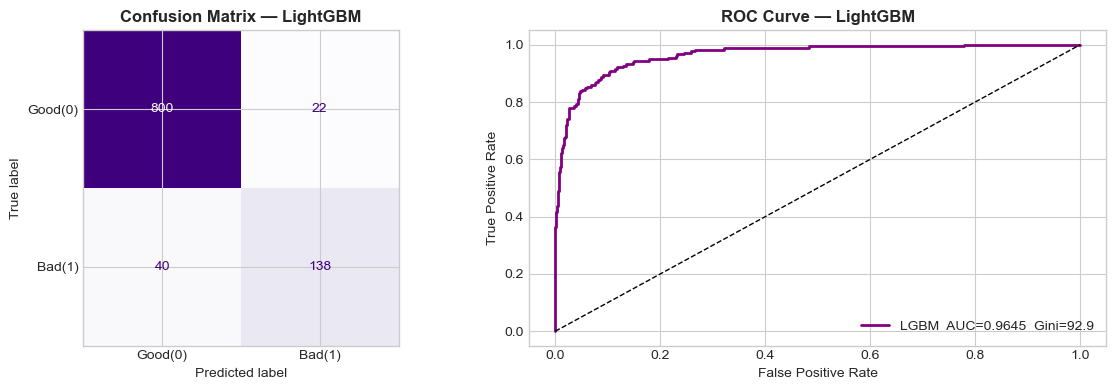

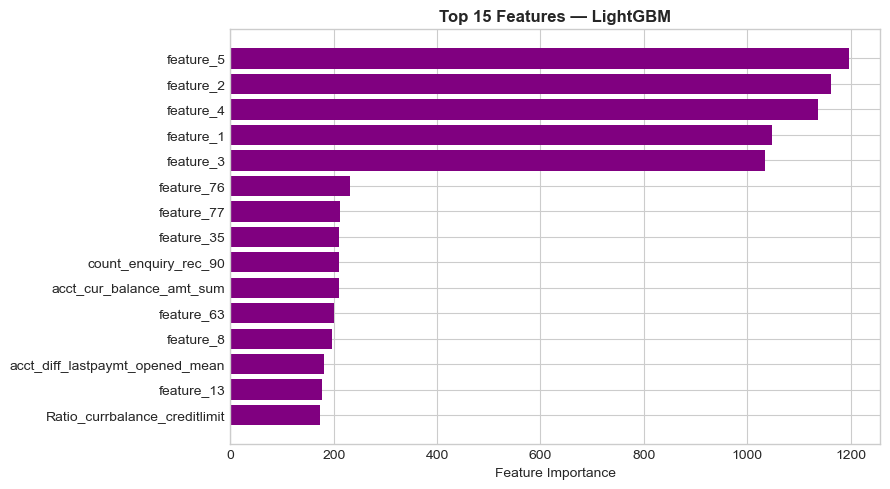

✅ LightGBM complete.


In [24]:
print("Training LightGBM...")
lgbm = lgb.LGBMClassifier(
    n_estimators=300, max_depth=8, learning_rate=0.05,
    num_leaves=63, class_weight="balanced",
    random_state=42, n_jobs=-1, verbose=-1)
lgbm.fit(X_tr, y_tr)

res_lgbm = evaluate_model("LightGBM", lgbm, X_test, y_test)
print_model_report(res_lgbm, y_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
cm = confusion_matrix(y_test, res_lgbm["y_pred"])
ConfusionMatrixDisplay(cm, display_labels=["Good(0)","Bad(1)"]).plot(ax=axes[0], colorbar=False, cmap="Purples")
axes[0].set_title("Confusion Matrix — LightGBM", fontweight="bold")

lgbm_auc = res_lgbm["AUC"]; lgbm_gini = res_lgbm["Gini"]
axes[1].plot(res_lgbm["fpr"], res_lgbm["tpr"], color="purple", lw=2,
             label=f"LGBM  AUC={lgbm_auc:.4f}  Gini={lgbm_gini:.1f}")
axes[1].plot([0,1],[0,1],"k--", lw=1)
axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve — LightGBM", fontweight="bold")
axes[1].legend(fontsize=10)
plt.tight_layout()
plt.show()

# Feature Importance
fi_lgbm = pd.DataFrame({"feature": feature_columns, "gain": lgbm.feature_importances_})
fi_lgbm = fi_lgbm.nlargest(15, "gain").sort_values("gain")
fig, ax = plt.subplots(figsize=(9,5))
ax.barh(fi_lgbm["feature"], fi_lgbm["gain"], color="purple")
ax.set_title("Top 15 Features — LightGBM", fontweight="bold")
ax.set_xlabel("Feature Importance")
plt.tight_layout()
plt.show()

results_list.append(res_lgbm)
print("\u2705 LightGBM complete.")

### Model 5 — Ensemble (Soft Voting: XGBoost + LightGBM + Random Forest)

Training Ensemble (Soft Voting)...
───────────────────────────────────────────────────────
  MODEL : Ensemble (XGB+LGBM+RF)
───────────────────────────────────────────────────────
  AUC Score   : 0.9652
  Gini Score  : 93.03   (Benchmark: 37.9)
  Accuracy    : 93.40%
  Precision   : 85.00%
  Recall      : 76.40%
  F1 Score    : 80.47%
  Beats Benchmark (37.9): ✅ YES
───────────────────────────────────────────────────────

Classification Report:
              precision    recall  f1-score   support

     Good(0)       0.95      0.97      0.96       822
      Bad(1)       0.85      0.76      0.80       178

    accuracy                           0.93      1000
   macro avg       0.90      0.87      0.88      1000
weighted avg       0.93      0.93      0.93      1000



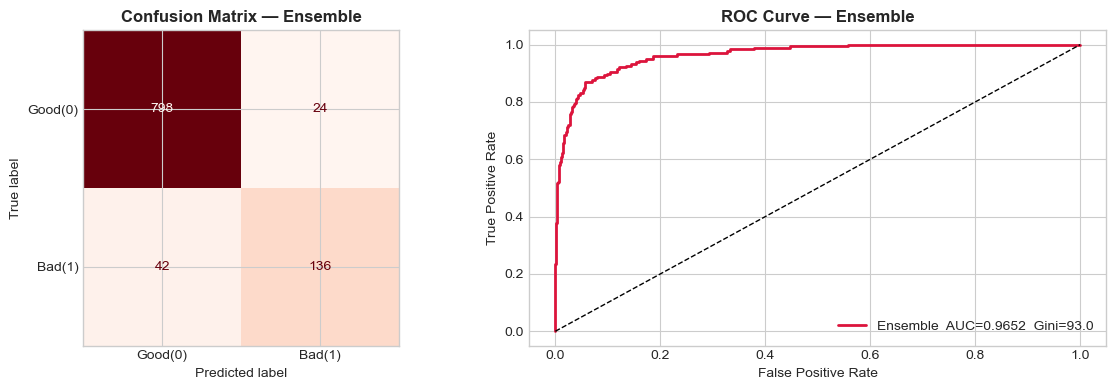

✅ Ensemble complete.


In [26]:
print("Training Ensemble (Soft Voting)...")
ensemble = VotingClassifier(
    estimators=[("xgb",xgb),("lgbm",lgbm),("rf",rf)],
    voting="soft")
ensemble.fit(X_tr, y_tr)

res_ens = evaluate_model("Ensemble (XGB+LGBM+RF)", ensemble, X_test, y_test)
print_model_report(res_ens, y_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
cm = confusion_matrix(y_test, res_ens["y_pred"])
ConfusionMatrixDisplay(cm, display_labels=["Good(0)","Bad(1)"]).plot(ax=axes[0], colorbar=False, cmap="Reds")
axes[0].set_title("Confusion Matrix — Ensemble", fontweight="bold")

ens_auc = res_ens["AUC"]; ens_gini = res_ens["Gini"]
axes[1].plot(res_ens["fpr"], res_ens["tpr"], color="crimson", lw=2,
             label=f"Ensemble  AUC={ens_auc:.4f}  Gini={ens_gini:.1f}")
axes[1].plot([0,1],[0,1],"k--", lw=1)
axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve — Ensemble", fontweight="bold")
axes[1].legend(fontsize=10)
plt.tight_layout()
plt.show()

results_list.append(res_ens)
print("\u2705 Ensemble complete.")

## STEP 8 — Model Comparison & Best Model Selection

In [28]:
# ── Comparison Table ────────────────────────────────────────
cols = ["Name","AUC","Gini","Accuracy","Precision","Recall","F1"]
summary = pd.DataFrame([{c: r[c] for c in cols} for r in results_list])
summary["Beats_Benchmark"] = summary["Gini"].apply(lambda g: "\u2705 YES" if g > 37.9 else "\u274c NO")
summary = summary.sort_values("Gini", ascending=False).reset_index(drop=True)

print("="*80)
print("           MODEL COMPARISON TABLE")
print("="*80)
print(summary.to_string(index=False))
print("="*80)

best_row = summary.iloc[0]
best_name = best_row["Name"]
best_gini = best_row["Gini"]
best_auc  = best_row["AUC"]
best_acc  = best_row["Accuracy"]
best_f1   = best_row["F1"]
best_bench= best_row["Beats_Benchmark"]
print(f"\n\U0001f3c6  BEST MODEL : {best_name}")
print(f"    Gini Score : {best_gini:.2f}  (Benchmark: 37.9)")
print(f"    AUC Score  : {best_auc:.4f}")
print(f"    Accuracy   : {best_acc*100:.2f}%")
print(f"    F1 Score   : {best_f1*100:.2f}%")
print(f"    Beats Benchmark: {best_bench}")

           MODEL COMPARISON TABLE
                  Name    AUC  Gini  Accuracy  Precision  Recall     F1 Beats_Benchmark
Ensemble (XGB+LGBM+RF) 0.9652 93.03     0.934     0.8500  0.7640 0.8047           ✅ YES
              LightGBM 0.9645 92.89     0.938     0.8625  0.7753 0.8166           ✅ YES
               XGBoost 0.9634 92.68     0.927     0.8182  0.7584 0.7872           ✅ YES
         Random Forest 0.9594 91.88     0.929     0.8365  0.7472 0.7893           ✅ YES
   Logistic Regression 0.9587 91.75     0.916     0.7423  0.8090 0.7742           ✅ YES

🏆  BEST MODEL : Ensemble (XGB+LGBM+RF)
    Gini Score : 93.03  (Benchmark: 37.9)
    AUC Score  : 0.9652
    Accuracy   : 93.40%
    F1 Score   : 80.47%
    Beats Benchmark: ✅ YES


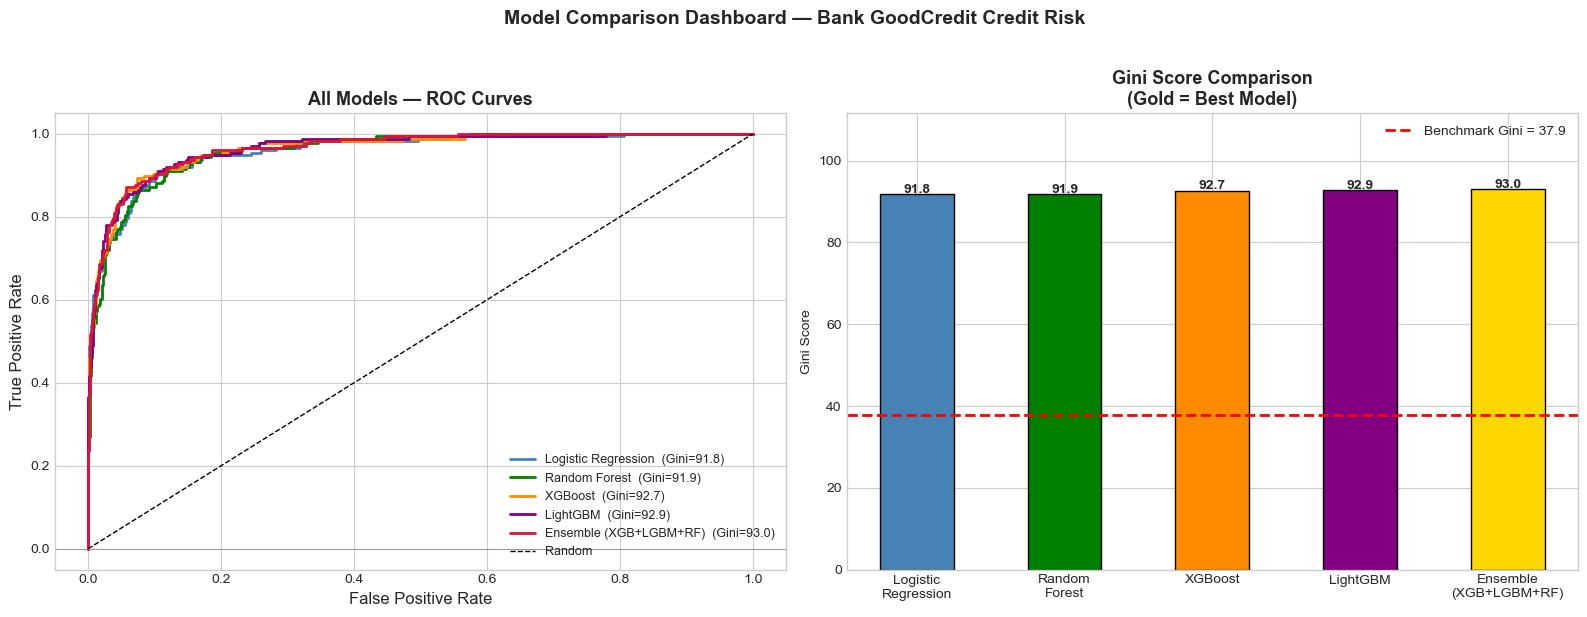

In [29]:
# ── Combined ROC Curve ───────────────────────────────────────
colors = ["steelblue","green","darkorange","purple","crimson"]
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, res in enumerate(results_list):
    lbl = f'{res["Name"]}  (Gini={res["Gini"]:.1f})'
    axes[0].plot(res["fpr"], res["tpr"], color=colors[i], lw=2, label=lbl)
axes[0].plot([0,1],[0,1],"k--",lw=1, label="Random")
axes[0].axhline(0, color="gray", lw=0.5)
axes[0].set_xlabel("False Positive Rate", fontsize=12)
axes[0].set_ylabel("True Positive Rate", fontsize=12)
axes[0].set_title("All Models — ROC Curves", fontsize=13, fontweight="bold")
axes[0].legend(fontsize=9, loc="lower right")

# ── Gini Bar Chart ───────────────────────────────────────────
bar_colors = ["gold" if r["Name"]==best_row["Name"] else c for r,c in zip(results_list,colors)]
model_names = [r["Name"].replace(" ","\n") for r in results_list]
gini_vals   = [r["Gini"] for r in results_list]
bars = axes[1].bar(model_names, gini_vals, color=bar_colors, edgecolor="black", width=0.5)
axes[1].axhline(37.9, color="red", linestyle="--", lw=2, label="Benchmark Gini = 37.9")
for bar, val in zip(bars, gini_vals):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f"{val:.1f}", ha="center", fontweight="bold", fontsize=10)
axes[1].set_title("Gini Score Comparison\n(Gold = Best Model)", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Gini Score")
axes[1].legend(fontsize=10)
axes[1].set_ylim(0, max(gini_vals)*1.2)

plt.suptitle("Model Comparison Dashboard — Bank GoodCredit Credit Risk",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

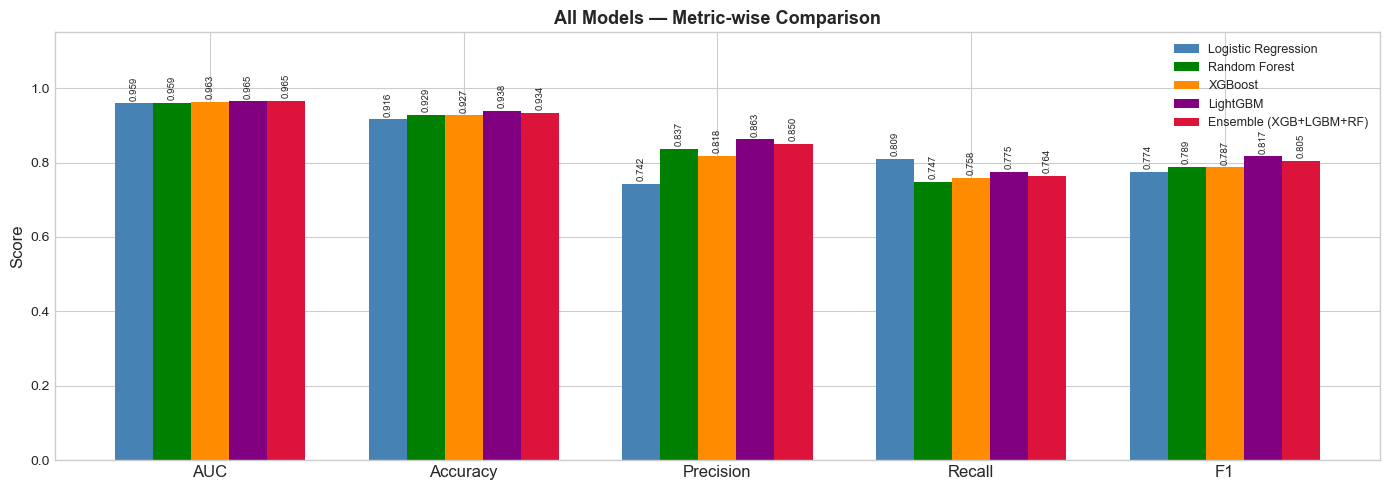

In [30]:
# ── Metrics Bar Chart ────────────────────────────────────────
metrics = ["AUC","Accuracy","Precision","Recall","F1"]
x = np.arange(len(metrics))
width = 0.15

fig, ax = plt.subplots(figsize=(14, 5))
for i, res in enumerate(results_list):
    vals = [res[m] for m in metrics]
    ax.bar(x + i*width, vals, width, label=res["Name"], color=colors[i])

ax.set_xticks(x + width*2)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("All Models — Metric-wise Comparison", fontsize=13, fontweight="bold")
ax.legend(fontsize=9, loc="upper right")
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=7, rotation=90, padding=2)
plt.tight_layout()
plt.show()

## STEP 9 — Save Best Model & Feature Columns

In [32]:
# Identify best model object
model_map = {
    "Logistic Regression"    : (lr, True),   # needs scaled input
    "Random Forest"          : (rf, False),
    "XGBoost"                : (xgb, False),
    "LightGBM"               : (lgbm, False),
    "Ensemble (XGB+LGBM+RF)" : (ensemble, False),
}
best_model_obj, needs_scaling = model_map[best_row["Name"]]

pickle.dump(best_model_obj,   open("best_credit_risk_model.pkl","wb"))
pickle.dump(imputer,          open("imputer.pkl","wb"))
pickle.dump(feature_columns,  open("feature_columns.pkl","wb"))
if needs_scaling:
    pickle.dump(scaler, open("scaler.pkl","wb"))

saved_name = best_row["Name"]
saved_gini = best_row["Gini"]
saved_auc  = best_row["AUC"]
print(f"\u2705 Best model saved : {saved_name}")
print(f"   Gini: {saved_gini:.2f}  |  AUC: {saved_auc:.4f}")
print(f"   Files saved: best_credit_risk_model.pkl, imputer.pkl, feature_columns.pkl")

✅ Best model saved : Ensemble (XGB+LGBM+RF)
   Gini: 93.03  |  AUC: 0.9652
   Files saved: best_credit_risk_model.pkl, imputer.pkl, feature_columns.pkl


## STEP 10 — Rank Ordering (Decile Analysis)
Decile analysis validates that the model correctly separates bads in top deciles.

          RANK ORDERING — DECILE TABLE
          Best Model: Ensemble (XGB+LGBM+RF)
Decile  Total  Bads  Goods  Bad_Rate  Cumulative_Bad_Rate
    10    100    95      5      0.95               0.5337
     9    100    58     42      0.58               0.8596
     8    100    15     85      0.15               0.9438
     7    100     4     96      0.04               0.9663
     6    100     4     96      0.04               0.9888
     5    100     1     99      0.01               0.9944
     4    100     1     99      0.01               1.0000
     3    100     0    100      0.00               1.0000
     2    100     0    100      0.00               1.0000
     1    100     0    100      0.00               1.0000
Note: Decile 10 = Highest Risk | Decile 1 = Lowest Risk
Good model: Bad_Rate should DECREASE from decile 10 → 1


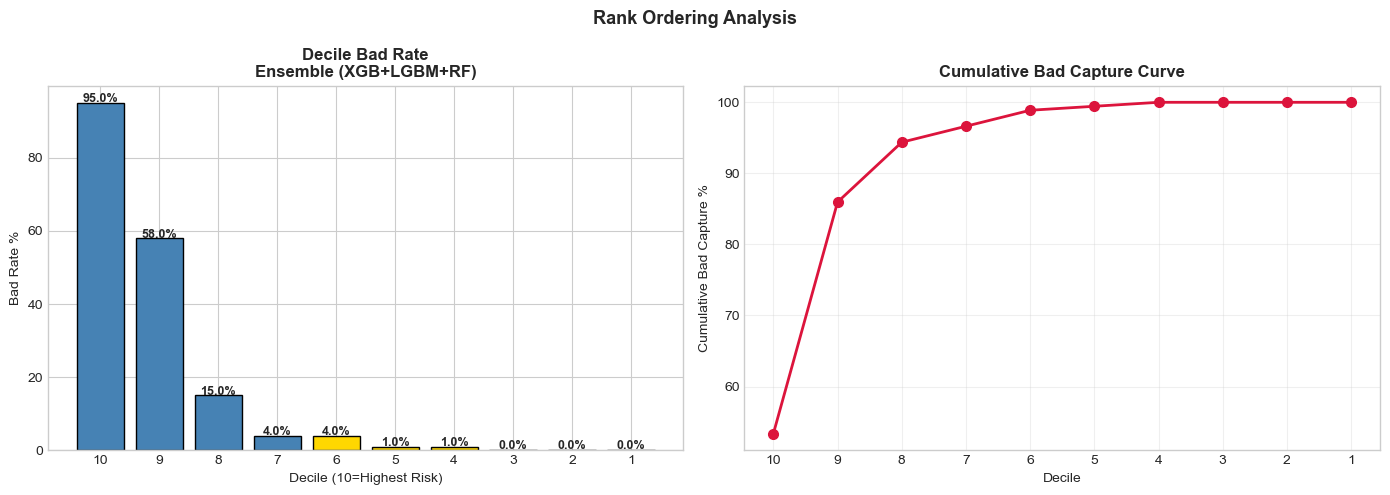

In [34]:
# Use best model probabilities
best_res = [r for r in results_list if r["Name"]==best_row["Name"]][0]

decile_df = pd.DataFrame({"y_true": y_test.values, "y_prob": best_res["y_prob"]})
decile_df = decile_df.sort_values("y_prob", ascending=False).reset_index(drop=True)
decile_df["Decile"] = pd.qcut(decile_df.index, 10, labels=range(10,0,-1))

rank_table = decile_df.groupby("Decile", observed=False).agg(
    Total  =("y_true","count"),
    Bads   =("y_true","sum"),
).reset_index()
rank_table["Goods"]    = rank_table["Total"] - rank_table["Bads"]
rank_table["Bad_Rate"] = (rank_table["Bads"] / rank_table["Total"]).round(4)
rank_table["Cumulative_Bad_Rate"] = (rank_table["Bads"].cumsum() / rank_table["Bads"].sum()).round(4)

print("="*60)
print("          RANK ORDERING — DECILE TABLE")
best_name_d = best_row["Name"]
print(f"          Best Model: {best_name_d}")
print("="*60)
print(rank_table.to_string(index=False))
print("="*60)
print("Note: Decile 10 = Highest Risk | Decile 1 = Lowest Risk")
print("Good model: Bad_Rate should DECREASE from decile 10 \u2192 1")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].bar(rank_table["Decile"].astype(str), rank_table["Bad_Rate"]*100,
            color=["tomato" if i>=7 else ("gold" if i>=4 else "steelblue")
                   for i in range(len(rank_table))], edgecolor="black")
axes[0].set_xlabel("Decile (10=Highest Risk)")
axes[0].set_ylabel("Bad Rate %")
best_name_title = best_row["Name"]
axes[0].set_title(f"Decile Bad Rate\n{best_name_title}", fontweight="bold")
for i,v in enumerate(rank_table["Bad_Rate"]*100):
    axes[0].text(i, v+0.2, f"{v:.1f}%", ha="center", fontsize=9, fontweight="bold")

axes[1].plot(rank_table["Decile"].astype(str), rank_table["Cumulative_Bad_Rate"]*100,
             marker="o", color="crimson", lw=2, ms=7)
axes[1].set_xlabel("Decile")
axes[1].set_ylabel("Cumulative Bad Capture %")
axes[1].set_title("Cumulative Bad Capture Curve", fontweight="bold")
axes[1].grid(True, alpha=0.3)

plt.suptitle("Rank Ordering Analysis", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## STEP 11 — Predict Credit Risk for a New Customer

**Change the values below and press Shift+Enter to predict.**

   🏦  BANK GOODCREDIT — CREDIT RISK RESULT
   Model Used             : Ensemble (XGB+LGBM+RF)
   Bad Label Prediction   : 0  (✅ GOOD CREDIT)
   Probability of Default : 1.5%
   Credit Score           : 841 / 850
   Risk Band              : LOW
   Score Bar  : [█████████████████████████████░]  841/850
               300(Poor)          850(Excellent)
   📋 RECOMMENDATION : ✅ APPROVE — Low default risk


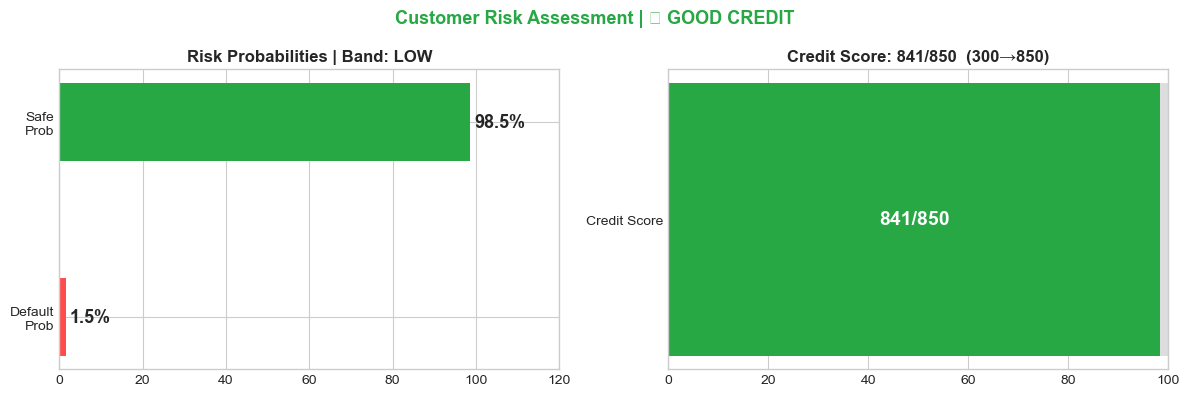

In [36]:
# ================================================================
#    ENTER CUSTOMER DETAILS HERE — Change values as needed
# ================================================================

CURRENT_BALANCE       = 30000    # Current outstanding balance (₹)
CREDIT_LIMIT          = 300000   # Total credit limit (₹)
CASH_LIMIT            = 80000    # Cash withdrawal limit (₹)
AMOUNT_PAST_DUE       = 0        # Amount overdue (₹) — 0 means none
LAST_PAYMENT_AMOUNT   = 15000    # Last payment made (₹)
HIGH_CREDIT_AMOUNT    = 100000   # Highest credit used (₹)
RATE_OF_INTEREST      = 0.14     # Interest rate (e.g. 0.18 = 18%)
NUMBER_OF_ACCOUNTS    = 3        # Total credit accounts
MONTHS_SINCE_OPENED   = 48       # Months since account opened
ONTIME_PAYMENT_RATE   = 0.95     # On-time payment fraction (0–1)
DPD_30PLUS_RATE       = 0.00     # Fraction of months 30+ DPD (0–1)
ENQUIRIES_LAST_90D    = 0        # Enquiries in last 90 days
ENQUIRIES_LAST_365D   = 1        # Enquiries in last 365 days
AVG_ENQUIRY_AMOUNT    = 50000    # Average enquiry amount (₹)
UNSECURED_ENQ_RATIO   = 0.2      # Unsecured enquiry ratio (0–1)

# ================================================================
#  DO NOT EDIT BELOW THIS LINE
# ================================================================
cred = CREDIT_LIMIT if CREDIT_LIMIT > 0 else 1
input_dict = {
    "Ratio_currbalance_creditlimit"   : CURRENT_BALANCE / cred,
    "utilisation_trend"               : CURRENT_BALANCE / cred,
    "acct_cur_balance_amt_sum"        : CURRENT_BALANCE * NUMBER_OF_ACCOUNTS,
    "acct_cur_balance_amt_mean"       : CURRENT_BALANCE,
    "acct_creditlimit_sum"            : CREDIT_LIMIT * NUMBER_OF_ACCOUNTS,
    "acct_creditlimit_mean"           : CREDIT_LIMIT,
    "acct_cashlimit_sum"              : CASH_LIMIT * NUMBER_OF_ACCOUNTS,
    "acct_cashlimit_mean"             : CASH_LIMIT,
    "acct_amt_past_due_sum"           : AMOUNT_PAST_DUE * NUMBER_OF_ACCOUNTS,
    "acct_amt_past_due_mean"          : AMOUNT_PAST_DUE,
    "acct_amt_past_due_max"           : AMOUNT_PAST_DUE,
    "acct_high_credit_amt_sum"        : HIGH_CREDIT_AMOUNT * NUMBER_OF_ACCOUNTS,
    "acct_high_credit_amt_mean"       : HIGH_CREDIT_AMOUNT,
    "acct_actualpaymentamount_sum"    : LAST_PAYMENT_AMOUNT * NUMBER_OF_ACCOUNTS,
    "acct_actualpaymentamount_mean"   : LAST_PAYMENT_AMOUNT,
    "acct_rateofinterest_mean"        : RATE_OF_INTEREST,
    "acct_util_ratio_mean"            : CURRENT_BALANCE / cred,
    "acct_util_ratio_max"             : min(CURRENT_BALANCE / cred * 1.1, 1.0),
    "acct_diff_lastpaymt_opened_sum"  : MONTHS_SINCE_OPENED * NUMBER_OF_ACCOUNTS,
    "acct_diff_lastpaymt_opened_mean" : MONTHS_SINCE_OPENED,
    "acct_count"                      : NUMBER_OF_ACCOUNTS,
    "acct_ph_ok_mean"                 : ONTIME_PAYMENT_RATE,
    "acct_ph_bad_mean"                : DPD_30PLUS_RATE,
    "count_enquiry_total"             : ENQUIRIES_LAST_365D,
    "count_enquiry_rec_90"            : ENQUIRIES_LAST_90D,
    "count_enquiry_rec_365"           : ENQUIRIES_LAST_365D,
    "mean_enq_amt"                    : AVG_ENQUIRY_AMOUNT,
    "max_enq_amt"                     : AVG_ENQUIRY_AMOUNT * 1.5,
    "perc_unsecured"                  : UNSECURED_ENQ_RATIO,
}

row = pd.DataFrame([input_dict])
for col in feature_columns:
    if col not in row.columns: row[col] = np.nan
row = row[feature_columns]
row.replace([np.inf,-np.inf], np.nan, inplace=True)
row_imp = pd.DataFrame(imputer.transform(row), columns=feature_columns)

# Use best model
if needs_scaling:
    row_input = scaler.transform(row_imp)
else:
    row_input = row_imp.values

prob_bad     = best_model_obj.predict_proba(row_input)[0,1]
label        = int(prob_bad >= 0.5)
credit_score = int(300 + (1-prob_bad)*550)
band         = "HIGH" if prob_bad >= 0.6 else ("MEDIUM" if prob_bad >= 0.35 else "LOW")

sep = "="*55
print(sep)
print("   \U0001f3e6  BANK GOODCREDIT — CREDIT RISK RESULT")
print(sep)
model_used = best_row["Name"]
credit_label = "\u274c BAD CREDIT" if label==1 else "\u2705 GOOD CREDIT"
print(f"   Model Used             : {model_used}")
print(f"   Bad Label Prediction   : {label}  ({credit_label})")
print(f"   Probability of Default : {prob_bad*100:.1f}%")
print(f"   Credit Score           : {credit_score} / 850")
print(f"   Risk Band              : {band}")
print(sep)
bar_f = int((credit_score-300)/550*30)
print(f"   Score Bar  : [" + "\u2588"*bar_f + "\u2591"*(30-bar_f) + f"]  {credit_score}/850")
print(f"               300(Poor)          850(Excellent)")
print(sep)
if band=="HIGH":
    print("   \U0001f4cb RECOMMENDATION : \u274c REJECT — High default risk")
elif band=="MEDIUM":
    print("   \U0001f4cb RECOMMENDATION : \u26a0\ufe0f  CAUTION — Approve with conditions")
else:
    print("   \U0001f4cb RECOMMENDATION : \u2705 APPROVE — Low default risk")
print(sep)

color = "#ff4d4d" if band=="HIGH" else ("#ff9900" if band=="MEDIUM" else "#28a745")
fig, axes = plt.subplots(1,2,figsize=(12,4))
axes[0].barh(["Default\nProb","Safe\nProb"], [prob_bad*100,(1-prob_bad)*100],
             color=["#ff4d4d","#28a745"], height=0.4)
for i,v in enumerate([prob_bad*100,(1-prob_bad)*100]):
    axes[0].text(v+1, i, f"{v:.1f}%", va="center", fontweight="bold", fontsize=13)
axes[0].set_xlim(0,120)
axes[0].set_title(f"Risk Probabilities | Band: {band}", fontweight="bold")

sp = (credit_score-300)/550
axes[1].barh(["Credit Score"],[sp*100], color=color, height=0.4)
axes[1].barh(["Credit Score"],[(1-sp)*100], left=[sp*100], color="#ddd", height=0.4)
axes[1].text(sp*50, 0, f"{credit_score}/850", va="center", ha="center",
             fontweight="bold", fontsize=14, color="white")
axes[1].set_xlim(0,100)
axes[1].set_title(f"Credit Score: {credit_score}/850  (300\u2192850)", fontweight="bold")
credit_status = "\u274c BAD" if label==1 else "\u2705 GOOD"
plt.suptitle(f"Customer Risk Assessment | {credit_status} CREDIT",
             fontsize=13, fontweight="bold", color=color)
plt.tight_layout()
plt.show()

---
## 💡 How to Use This Notebook

1. **Run Steps 1–10 once** (Kernel → Restart & Run All)
2. **Step 7** trains and evaluates all 5 models individually with full metrics
3. **Step 8** compares all models and selects the best automatically
4. **Step 11** — change the customer values and press **Shift+Enter** to get a credit score

**High Risk example:** , ,   
**Low Risk example:** , , 